#Chapter 6. 합성곱 신경망 II - Part 2(6.1.5~)

#6.1 이미지 분류를 위한 신경망

##6.1.5 ResNet

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import matplotlib.pyplot as plt
import numpy as np

import copy
from collections import namedtuple
import os
import random
import time

import cv2
from torch.utils.data import Dataset, DataLoader
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
class ImageTransform():
  def __init__(self, resize, mean, std):
    self.data_transform = {
        #훈련 이미지 데이터에 대한 전처리
        'train': transforms.Compose([
            transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        #검증과 테스트 이미지 데이터에 대한 전처리
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    }

  def __call__(self, img, phase):
    return self.data_transform[phase](img)

In [14]:
size = 224
mean = (0.486, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

In [38]:
cat_directory = '/content/Cat/'
dog_directory = '/content/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in os.listdir(cat_directory)])
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in os.listdir(dog_directory)])

image_filepaths = [*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths = [i for i in image_filepaths if cv2.imread(i) is not None]

In [16]:
random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:-10]
test_images_filepaths = correct_images_filepaths[-10:]
print(len(train_images_filepaths), len(val_images_filepaths),
      len(test_images_filepaths))

400 92 10


In [17]:
class DogvsCatDataset(Dataset):
  def __init__(self, file_list, transform=None, phase='train'):
    self.file_list = file_list
    self.transform = transform
    self.phase = phase

  def __len__(self):
    return len(self.file_list)

  def __getitem__(self, idx):
    img_path = self.file_list[idx]
    img = Image.open(img_path)
    img_transformed = self.transform(img, self.phase)

    label = img_path.split('/')[-1].split('.')[0]
    if label == 'dog':
      label = 1
    elif label == 'cat':
      label = 0
    return img_transformed, label

In [18]:
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size,
                mean, std), phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size,
              mean, std), phase='val')
index = 0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

torch.Size([3, 224, 224])
0


In [19]:
train_iterator = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_iterator = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict = {'train': train_iterator, 'val':val_iterator} #훈련 데이터셋과 검증 데이터셋을 합쳐서 표현

batch_iterator = iter(train_iterator)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

torch.Size([32, 3, 224, 224])
tensor([0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1,
        1, 1, 1, 1, 0, 1, 1, 0])


In [20]:
class BasicBlock(nn.Module):
  expansion = 1

  def __init__(self, in_channels, out_channels, stride=1, downsample=False):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                           stride=stride, padding=1, bias=False) #3x3 합성곱층
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                           stride=1, padding=1, bias=False) #3x3 합성곱층
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU(inplace=True)

    if downsample:
      conv = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                       stride=stride, bias=False)
      bn = nn.BatchNorm2d(out_channels)
      downsample = nn.Sequential(conv, bn)
    else:
      downsample = None
    self.downsample = downsample

  def forward(self, x):
    i = x
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.bn2(x)

    if self.downsample is not None:
      i = self.downsample(i)

    x += i
    x = self.relu(x)
    return x

In [21]:
class Bottleneck(nn.Module):
  expansion = 4 #ResNet에서 병목 블록을 정의하기 위한 파라미터

  def __init__(self, in_channels, out_channels, stride=1, downsample=False):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                           stride=1, bias=False) #1x1 합성곱층
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                           stride=stride, padding=1, bias=False) #3x3 합성
    self.bn2 = nn.BatchNorm2d(out_channels)
    #1x1 합성곱층, 또한 다음 계층의 입력 채널 수와 일치하도록 self.expansion*out_channels
    self.conv3 = nn.Conv2d(out_channels, self.expansion*out_channels,
                          kernel_size=1, stride=1, bias=False)
    self.bn3 = nn.BatchNorm2d(self.expansion*out_channels)
    self.relu = nn.ReLU(inplace=True)

    if downsample:
      conv = nn.Conv2d(in_channels, self.expansion*out_channels, kernel_size=1,
                       stride=stride, bias=False)
      bn = nn.BatchNorm2d(self.expansion*out_channels)
      downsample = nn.Sequential(conv, bn)
    else:
      downsample = None
    self.downsample = downsample

  def forward(self, x):
    i = x
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)
    x = self.conv3(x)
    x = self.bn3(x)

    if self.downsample is not None:
      i = self.downsample(i)

    x += i
    x = self.relu(x)
    return x

In [22]:
class ResNet(nn.Module):
  def __init__(self, config, output_dim, zero_init_residual=False):
    super().__init__()

    #ResNet을 호출할 때 넘겨준 config 값들을 bolck, n_blocks, channels에 저장
    block, n_blocks, channels = config
    self.in_channels = channels[0]
    assert len(n_blocks) == len(channels) == 4 #블록크기=채널크기=4

    self.conv1 = nn.Conv2d(3, self.in_channels, kernel_size=7, stride=2,
                           padding=3, bias=False)
    self.bn1 = nn.BatchNorm2d(self.in_channels)
    self.relu = nn.ReLU(inplace=True)
    self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

    self.layer1 = self.get_resnet_layer(block, n_blocks[0], channels[0])
    self.layer2 = self.get_resnet_layer(block, n_blocks[1], channels[1], stride=2)
    self.layer3 = self.get_resnet_layer(block, n_blocks[2], channels[2], stride=2)
    self.layer4 = self.get_resnet_layer(block, n_blocks[3], channels[3], stride=2)

    self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    self.fc = nn.Linear(self.in_channels, output_dim)

    if zero_init_residual:
      for m in self.modules():
        if isinstance(m, Bottleneck):
          nn.init.constant_(m.bn3.weight, 0)
        elif isinstance(m, BasicBlock):
          nn.init.constant_(m.bn2.weight, 0)

  #블록을 추가하기 위한 함수
  def get_resnet_layer(self, block, n_blocks, channels, stride=1):
    layers = []
    #in_channels와 block.expansion*channels가 다르면 downsample 적용
    if self.in_channels != block.expansion*channels:
      downsample = True
    else:
      downsample = False

    #계층을 추가할 때 in_channels, channels, stride뿐만 아니라 다운샘플 적용 유무도 함께 전달
    layers.append(block(self.in_channels, channels, stride, downsample))
    for i in range(1, n_blocks): #n_blocks만큼 계층 추가
      layers.append(block(block.expansion*channels, channels))

    self.in_channels = block.expansion*channels
    return nn.Sequential(*layers)

  def forward(self, x):
    x = self.conv1(x) #224x224
    x = self.bn1(x)
    x = self.relu(x)
    x = self.maxpool(x) #112x112

    x = self.layer1(x) #56x56
    x = self.layer2(x) #28x28
    x = self.layer3(x) #14x14
    x = self.layer4(x) #7x7

    x = self.avgpool(x) #1x1
    h = x.view(x.shape[0], -1)
    x = self.fc(h)
    return x,h

In [23]:
ResNetConfig = namedtuple('ResNetConfig',['block','n_blocks','channels'])

In [24]:
resnet18_config = ResNetConfig(block=BasicBlock,
                               n_blocks=[2,2,2,2],
                               channels=[64,128,256,512])
resnet34_config = ResNetConfig(block=BasicBlock,
                               n_blocks=[3,4,6,3],
                               channels=[64,128,256,512])

In [25]:
resnet50_config = ResNetConfig(block=Bottleneck,
                               n_blocks=[3,4,6,3],
                               channels=[64,128,256,512])

resnet101_config = ResNetConfig(block=Bottleneck,
                                n_blocks=[3,4,23,3],
                                channels=[64,128,256,512])

resnet152_config = ResNetConfig(block=Bottleneck,
                                n_blocks=[3,8,36,3],
                                channels=[64,128,256,512])

In [26]:
pretrained_model = models.resnet50(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


In [27]:
print(pretrained_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [28]:
OUTPUT_DIM = 2 #두 개의 클래스 사용(개와 고양이)
model = ResNet(resnet50_config, OUTPUT_DIM)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [29]:
optimizer = optim.Adam(model.parameters(), lr=1e-7) #lr=1e-7은 1*10의 -7승을 의미
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

In [30]:
def calculate_topk_accuracy(y_pred, y, k=2):
  with torch.no_grad():
    batch_size = y.shape[0]
    _, top_pred = y_pred.topk(k, 1)
    top_pred = top_pred.t()
    correct = top_pred.eq(y.view(1, -1).expand_as(top_pred))
    correct_1 = correct[:1].reshape(-1).float().sum(0, keepdim=True)
    #이미지의 정확한 레이블 부여를 위해 사용
    #즉, 첫 번째 레이블이 아닌 정확한 레이블 부여를 위해 사용
    correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
    acc_1 = correct_1 / batch_size
    acc_k = correct_k / batch_size
  return acc_1, acc_k

In [31]:
def train(model, iterator, optimizer, criterion, device):
  epoch_loss=0
  epoch_acc_1=0
  epoch_acc_5=0
  model.train()

  for (x,y) in iterator:
    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad()
    y_pred = model(x)
    loss = criterion(y_pred[0], y)

    acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()
    #모델이 첫 번째로 예측한 레이블이 붙여진다
    epoch_acc_1 += acc_1.item()
    #이미지에 정확한 레이블이 붙여질 것이기 때문에 정확도가 100%
    epoch_acc_5 += acc_5.item()

  epoch_loss /= len(iterator)
  epoch_acc_1 /= len(iterator)
  epoch_acc_5 /= len(iterator)
  return epoch_loss, epoch_acc_1, epoch_acc_5

In [32]:
def evaluate(model, iterator, criterion, device):
  epoch_loss=0
  epoch_acc_1=0
  epoch_acc_5=0

  model.eval()
  with torch.no_grad():
    for (x,y) in iterator:
      x = x.to(device)
      y = y.to(device)
      y_pred = model(x)
      loss = criterion(y_pred[0], y)

      acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)
      epoch_loss += loss.item()
      epoch_acc_1 += acc_1.item()
      epoch_acc_5 += acc_5.item()

  epoch_loss /= len(iterator)
  epoch_acc_1 /= len(iterator)
  epoch_acc_5 /= len(iterator)
  return epoch_loss, epoch_acc_1, epoch_acc_5

In [33]:
def epoch_time(start_time, end_time):
  elapsed_time = end_time - start_time
  elapsed_mins = int(elapsed_time / 60)
  elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
  return elapsed_mins, elapsed_secs

In [35]:
best_valid_loss = float('inf')
EPOCHS = 10

for epoch in range(EPOCHS):
  start_time = time.monotonic()

  train_loss, train_acc_1, train_acc_5 = train(model, train_iterator, optimizer,
                                              criterion, device)
  valid_loss, valid_acc_1, valid_acc_5 = evaluate(model, val_iterator,
                                                  criterion, device)
  if valid_loss < best_valid_loss:
    best_valid_loss = valid_loss
    torch.save(model.state_dict(), '/content/drive/MyDrive/Euron9thDL/ResNet-model.pt')

  end_time = time.monotonic()
  epoch_mins, epoch_secs = epoch_time(start_time, end_time)
  print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
  print(f'\tTrain Loss: {train_loss:.3f} | Train Acc@1: {train_acc_1*100:6.2f}% | Train Acc@5: {train_acc_5*100:6.2f}%')
  print(f'\tValid Loss: {valid_loss:.3f} | Valid Acc@1: {valid_acc_1*100:6.2f}% | Valid Acc@5: {valid_acc_5*100:6.2f}%')

Epoch: 01 | Epoch Time: 3m 3s
	Train Loss: 0.700 | Train Acc@1:  51.92% | Train Acc@5: 100.00%
	Valid Loss: 0.709 | Valid Acc@1:  44.79% | Valid Acc@5: 100.00%
Epoch: 02 | Epoch Time: 2m 58s
	Train Loss: 0.705 | Train Acc@1:  48.56% | Train Acc@5: 100.00%
	Valid Loss: 0.736 | Valid Acc@1:  44.79% | Valid Acc@5: 100.00%
Epoch: 03 | Epoch Time: 2m 59s
	Train Loss: 0.704 | Train Acc@1:  48.56% | Train Acc@5: 100.00%
	Valid Loss: 0.720 | Valid Acc@1:  44.79% | Valid Acc@5: 100.00%
Epoch: 04 | Epoch Time: 2m 57s
	Train Loss: 0.701 | Train Acc@1:  49.76% | Train Acc@5: 100.00%
	Valid Loss: 0.716 | Valid Acc@1:  44.79% | Valid Acc@5: 100.00%
Epoch: 05 | Epoch Time: 2m 58s
	Train Loss: 0.694 | Train Acc@1:  49.76% | Train Acc@5: 100.00%
	Valid Loss: 0.709 | Valid Acc@1:  43.75% | Valid Acc@5: 100.00%
Epoch: 06 | Epoch Time: 2m 58s
	Train Loss: 0.701 | Train Acc@1:  48.56% | Train Acc@5: 100.00%
	Valid Loss: 0.703 | Valid Acc@1:  41.82% | Valid Acc@5: 100.00%
Epoch: 07 | Epoch Time: 2m 57s
	Tra

In [36]:
import pandas as pd
id_list = []
pred_list = []
_id=0
with torch.no_grad():
    for test_path in test_images_filepaths:
        img = Image.open(test_path)
        _id =test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs[0], dim=1)[:, 1].tolist()
        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)

res.to_csv('/content/drive/MyDrive/Euron9thDL/ResNet.csv', index=False)
res.head(10)

,id,label
0,128,0.524350
1,133,0.599420
2,170,0.605775
3,18,0.509062
4,185,0.537062
5,219,0.494820
6,31,0.515170
7,34,0.540599
8,86,0.546541
9,93,0.523677


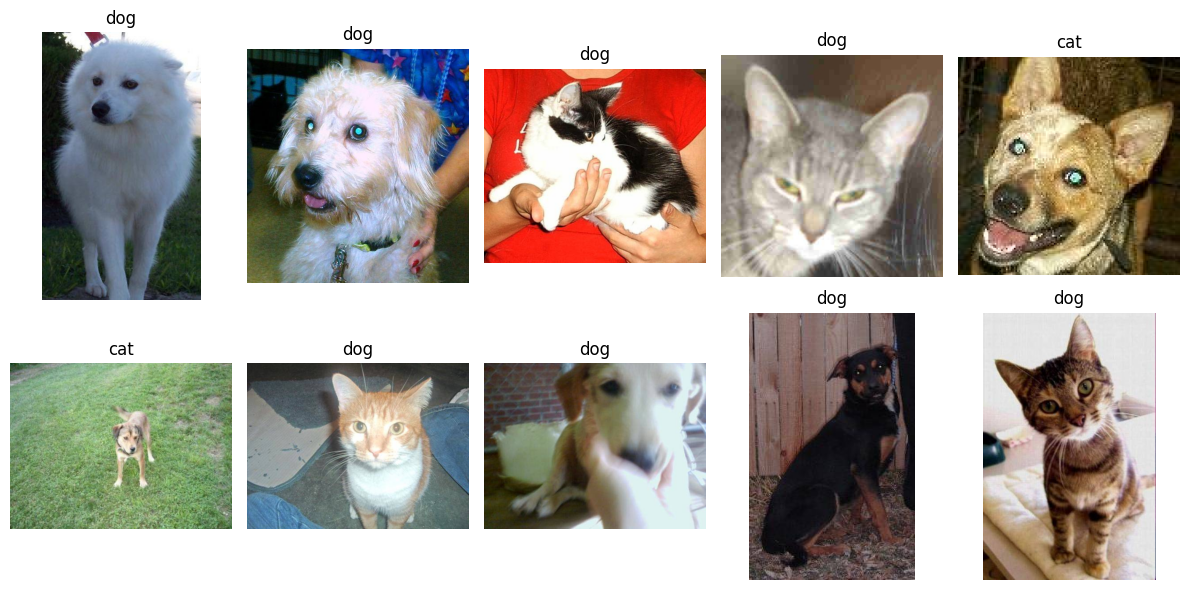

In [37]:
class_ = classes = {0:'cat', 1:'dog'}
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))
    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        a = random.choice(res['id'].values)
        label = res.loc[res['id'] == a, 'label'].values[0]

        if label > 0.5:
            label = 1
        else:
            label = 0
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()
    plt.tight_layout()
    plt.show()
display_image_grid(test_images_filepaths)